In [1]:
import os
os.environ["KAGGLEHUB_CACHE"] = "/home/fedosdan2/Study/TCP/seminars/sem_2_upset_plot"  

import kagglehub
path = kagglehub.dataset_download("prince1204/handling-missing-data-example-dataset")

print("Path to dataset files:", path)

/home/fedosdan2/miniconda3/envs/sdt/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /home/fedosdan2/Study/TCP/seminars/sem_2_upset_plot/datasets/prince1204/handling-missing-data-example-dataset/versions/1


In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from itertools import combinations

df = pd.read_csv('/home/fedosdan2/Study/TCP/seminars/sem_2_upset_plot/datasets/prince1204/handling-missing-data-example-dataset/versions/1/Handle_Missing_Data.csv')

print(f"✅ Загружено записей: {len(df)}")
print(f" Колонки: {list(df.columns)}")
print(f"\n📊 Первые 5 строк:")
display(df.head())

✅ Загружено записей: 1000
 Колонки: ['ID', 'Age', 'Salary', 'Experience', 'Department', 'City']

📊 Первые 5 строк:


,ID,Age,Salary,Experience,Department,City
0,1,56.0,39382.0,3.0,NaN,London
1,2,NaN,109291.0,37.0,Finance,Berlin
2,3,32.0,28756.0,18.0,IT,London
3,4,25.0,45609.0,5.0,Sales,New York
4,5,NaN,41478.0,33.0,Admin,London


In [3]:
# Колонки с пропусками
missing_cols = ['Age', 'Salary', 'Experience', 'Department', 'City']

# Создаем булевы индикаторы пропусков (True = пропуск, False = значение есть)
for col in missing_cols:
    df[f'{col}_missing'] = df[col].isna()

# Списки для удобства
indicator_cols = [f'{col}_missing' for col in missing_cols]
abbreviations = ['Age', 'Salary', 'Exp', 'Dept', 'City']

print("✅ Индикаторы пропусков созданы")
print(f"📌 Индикаторные колонки: {indicator_cols}")
print(f" Аббревиатуры: {abbreviations}")

✅ Индикаторы пропусков созданы
📌 Индикаторные колонки: ['Age_missing', 'Salary_missing', 'Experience_missing', 'Department_missing', 'City_missing']
 Аббревиатуры: ['Age', 'Salary', 'Exp', 'Dept', 'City']


In [4]:
def compute_intersections(df, indicator_cols):
    """
    Вычисляет все непустые пересечения множеств.
    
    Возвращает словарь:
    - ключ: кортеж индексов множеств (например, (0, 2) = Age ∩ Exp)
    - значение: количество записей в пересечении
    """
    n_sets = len(indicator_cols)
    intersections = {}
    
    # Перебираем все возможные комбинации (от 1 до n_sets)
    for r in range(1, n_sets + 1):
        for combo in combinations(range(n_sets), r):
            # Создаем маску: все выбранные множества должны быть True
            mask = pd.Series([True] * len(df), index=df.index)
            for idx in combo:
                mask &= df[indicator_cols[idx]]
            
            count = mask.sum()
            
            if count > 0:
                intersections[combo] = count
    
    return intersections

# Вычисляем пересечения
intersections = compute_intersections(df, indicator_cols)

# Показываем топ-10 пересечений
sorted_intersections = sorted(intersections.items(), key=lambda x: x[1], reverse=True)

print(f"📊 Найдено {len(sorted_intersections)} непустых пересечений\n")
print("Топ-10 пересечений:")
print("=" * 50)
for i, (combo, count) in enumerate(sorted_intersections[:10]):
    sets_names = [abbreviations[idx] for idx in combo]
    print(f"{i+1:2}. {' ∩ '.join(sets_names):25} : {count:4} записей")

📊 Найдено 19 непустых пересечений

Топ-10 пересечений:
 1. Age                       :  100 записей
 2. Salary                    :  100 записей
 3. Exp                       :  100 записей
 4. Dept                      :  100 записей
 5. City                      :  100 записей
 6. Age ∩ Exp                 :   16 записей
 7. Exp ∩ City                :   14 записей
 8. Salary ∩ Exp              :   12 записей
 9. Dept ∩ City               :   11 записей
10. Salary ∩ City             :    8 записей


In [5]:
def plot_upset(df, indicator_cols, abbreviations, intersections, 
               orientation='horizontal', max_intersections=50, figsize=None):
    """
    Строит UpSet plot с возможностью переключения ориентации.
    
    Параметры:
    - orientation: 'horizontal' (по умолчанию) или 'vertical'
    - max_intersections: максимальное количество пересечений для отображения
    - figsize: размер фигуры (автоматически подбирается, если None)
    
    Возвращает: matplotlib figure
    """
    
    # Сортируем и ограничиваем количество пересечений
    intersections = sorted(intersections.items(), key=lambda x: x[1], reverse=True)
    
    n_sets = len(indicator_cols)
    n_intersections = len(intersections)
    
    # Автоматически подбираем размер фигуры
    if figsize is None:
        if orientation == 'horizontal':
            figsize = (16, 10)
        else:
            figsize = (14, 12)
    
    fig = plt.figure(figsize=figsize)
    
    if orientation == 'horizontal':
        # === ГОРИЗОНТАЛЬНАЯ ОРИЕНТАЦИЯ ===
        gs = fig.add_gridspec(2, 2, height_ratios=[3, 2], 
                              width_ratios=[1, 4],
                              hspace=0.1, wspace=0.1)
        
        ax_hist_vert = fig.add_subplot(gs[0, 1])   # Верх: гистограмма пересечений
        ax_matrix = fig.add_subplot(gs[1, 1])       # Низ справа: матрица
        ax_hist_horiz = fig.add_subplot(gs[1, 0])   # Низ слева: гистограмма множеств
        
        # --- Вертикальная гистограмма пересечений ---
        intersection_counts = [count for _, count in intersections]
        x_positions = np.arange(n_intersections)
        
        bars = ax_hist_vert.bar(x_positions, intersection_counts, 
                                color='steelblue', edgecolor='black', linewidth=1.0)
        
        for bar, count in zip(bars, intersection_counts):
            height = bar.get_height()
            ax_hist_vert.text(bar.get_x() + bar.get_width()/2., height,
                             f'{count}', ha='center', va='bottom', fontsize=9)
        
        ax_hist_vert.set_xlim(-0.5, n_intersections - 0.5)
        ax_hist_vert.set_ylabel('Количество записей', fontsize=11, fontweight='bold')
        ax_hist_vert.set_title('Размеры пересечений', fontsize=12, fontweight='bold', pad=10)
        ax_hist_vert.grid(axis='y', alpha=0.3, linestyle='--')
        ax_hist_vert.spines['top'].set_visible(False)
        ax_hist_vert.spines['right'].set_visible(False)
        ax_hist_vert.set_xticks([])
        
        # --- Матрица пересечений ---
        # Толстые горизонтальные линии для каждого признака
        for idx in range(n_sets):
            ax_matrix.plot([-0.5, n_intersections - 0.5], [idx, idx], 
                          '-', color='#CCCCCC', linewidth=30, zorder=1)
        
        # Серые точки для ВСЕХ позиций
        for i in range(n_intersections):
            for idx in range(n_sets):
                ax_matrix.plot(i, idx, 'o', color='#E0E0E0', markersize=8, 
                            markeredgecolor='#E0E0E0', markeredgewidth=1.5, zorder=2)

        # Черные точки для активных пересечений
        for i, (combo, count) in enumerate(intersections):
            for idx in combo:
                ax_matrix.plot(i, idx, 'o', color='black', markersize=8, 
                            markeredgecolor='black', markeredgewidth=1.5, zorder=3)
            
            # Соединительные линии
            if len(combo) > 1:
                sorted_combo = sorted(combo)
                y_coords = [idx for idx in sorted_combo]
                x_coords = [i] * len(y_coords)
                ax_matrix.plot(x_coords, y_coords, '-', color='black', linewidth=5, zorder=3)
        
        ax_matrix.set_xlim(-0.5, n_intersections - 0.5)
        ax_matrix.set_ylim(-0.5, n_sets - 0.5)
        ax_matrix.invert_yaxis()
        ax_matrix.set_xticks([])
        ax_matrix.set_xlabel('Пересечения', fontsize=11, fontweight='bold', labelpad=10)
        ax_matrix.grid(False)
        ax_matrix.spines['top'].set_visible(False)
        ax_matrix.spines['right'].set_visible(False)
        ax_matrix.spines['bottom'].set_visible(False)
        
        # --- Горизонтальная гистограмма множеств ---
        set_sizes = [df[col].sum() for col in indicator_cols]
        y_positions = np.arange(n_sets)
        
        bars_horiz = ax_hist_horiz.barh(y_positions, set_sizes, 
                                         color='coral', edgecolor='black', linewidth=0.5)
        
        for bar, size in zip(bars_horiz, set_sizes):
            width = bar.get_width()
            ax_hist_horiz.text(width, bar.get_y() + bar.get_height()/2.,
                              f' {size}', ha='left', va='center', fontsize=10)
        
        ax_hist_horiz.set_ylim(-0.5, n_sets - 0.5)
        ax_hist_horiz.set_yticks(range(n_sets))
        ax_hist_horiz.set_yticklabels(abbreviations, fontsize=11, fontweight='bold')
        ax_hist_horiz.invert_yaxis()
        ax_hist_horiz.set_xlabel('Количество пропусков', fontsize=11, fontweight='bold')
        ax_hist_horiz.set_title('Размеры множеств', fontsize=12, fontweight='bold', pad=10)
        ax_hist_horiz.grid(axis='x', alpha=0.3, linestyle='--')
        ax_hist_horiz.spines['top'].set_visible(False)
        ax_hist_horiz.spines['right'].set_visible(False)
        
        title = 'UpSet Plot (горизонтальная ориентация): Паттерны пропущенных значений'
    
    else:  # orientation == 'vertical'
        # === ВЕРТИКАЛЬНАЯ ОРИЕНТАЦИЯ ===
        gs = fig.add_gridspec(2, 2, height_ratios=[1, 4], width_ratios=[2, 3], hspace=0.1, wspace=0.1)
        
        ax_hist_horiz_top = fig.add_subplot(gs[0, 0])   # Верх СЛЕВА: гистограмма множеств
        ax_matrix = fig.add_subplot(gs[1, 0])            # Низ слева: матрица
        ax_hist_horiz = fig.add_subplot(gs[1, 1])        # Низ справа: гистограмма пересечений
        
        # --- Горизонтальная гистограмма множеств ---
        set_sizes = [df[col].sum() for col in indicator_cols]
        x_positions = np.arange(n_sets)
        
        bars_top = ax_hist_horiz_top.bar(x_positions, set_sizes, color='coral', edgecolor='black', linewidth=0.5)
        
        for bar, size in zip(bars_top, set_sizes):
            height = bar.get_height()
            ax_hist_horiz_top.text(bar.get_x() + bar.get_width()/2., height, f'{size}', ha='center', va='bottom', fontsize=10)
        
        ax_hist_horiz_top.set_xlim(-0.5, n_sets - 0.5)
        ax_hist_horiz_top.set_ylabel('Количество пропусков', fontsize=11, fontweight='bold')
        ax_hist_horiz_top.set_title('Размеры множеств', fontsize=12, fontweight='bold', pad=10)
        ax_hist_horiz_top.grid(axis='y', alpha=0.3, linestyle='--')
        ax_hist_horiz_top.spines['top'].set_visible(False)
        ax_hist_horiz_top.spines['right'].set_visible(False)
        ax_hist_horiz_top.set_xticks([])
        
        intersections = sorted(intersections, key=lambda x: x[1], reverse=False)
        
        # --- Матрица пересечений (вертикальная) ---
        # Толстые вертикальные линии для каждого признака
        for idx in range(n_sets):
            ax_matrix.plot([idx, idx], [-0.5, n_intersections - 0.5], 
                          '-', color='#CCCCCC', linewidth=30, zorder=1)
        
        # Серые точки
        for i in range(n_intersections):
            for idx in range(n_sets):
                ax_matrix.plot(idx, i, 'o', color='#E0E0E0', markersize=8, 
                            markeredgecolor='#E0E0E0', markeredgewidth=1.5, zorder=2)


        # Черные точки
        for i, (combo, count) in enumerate(intersections):
            for idx in combo:
                ax_matrix.plot(idx, i, 'o', color='black', markersize=8, markeredgecolor='black', markeredgewidth=1.5, zorder=3)
                    
            # Соединительные линии
            if len(combo) > 1:
                sorted_combo = sorted(combo)
                x_coords = [idx for idx in sorted_combo]
                y_coords = [i] * len(x_coords)
                ax_matrix.plot(x_coords, y_coords, '-', color='black', linewidth=5, zorder=3)
        
        ax_matrix.set_xlim(-0.5, n_sets - 0.5)
        ax_matrix.set_ylim(-0.5, n_intersections - 0.5)
        ax_matrix.set_xticks(range(n_sets))
        ax_matrix.set_xticklabels(abbreviations, fontsize=11, fontweight='bold', rotation=45, ha='right')
        ax_matrix.set_yticks([])
        ax_matrix.set_ylabel('Пересечения', fontsize=11, fontweight='bold', labelpad=10)
        ax_matrix.grid(False)
        ax_matrix.spines['top'].set_visible(False)
        ax_matrix.spines['right'].set_visible(False)
        ax_matrix.spines['bottom'].set_visible(False)
        
        # --- Горизонтальная гистограмма пересечений ---
        intersection_counts = [count for _, count in intersections]
        y_positions = np.arange(n_intersections)
        
        bars = ax_hist_horiz.barh(y_positions, intersection_counts, 
                                   color='steelblue', edgecolor='black', linewidth=0.5)
        
        for bar, count in zip(bars, intersection_counts):
            width = bar.get_width()
            ax_hist_horiz.text(width, bar.get_y() + bar.get_height()/2.,
                              f' {count}', ha='left', va='center', fontsize=9)
        
        ax_hist_horiz.set_ylim(-0.5, n_intersections - 0.5)
        ax_hist_horiz.set_yticks([])
        ax_hist_horiz.set_xlabel('Количество записей', fontsize=11, fontweight='bold')
        ax_hist_horiz.set_title('Размеры пересечений', fontsize=12, fontweight='bold', pad=10)
        ax_hist_horiz.grid(axis='x', alpha=0.3, linestyle='--')
        ax_hist_horiz.spines['top'].set_visible(False)
        ax_hist_horiz.spines['right'].set_visible(False)
        
        title = 'UpSet Plot (вертикальная ориентация): Паттерны пропущенных значений'
    
    # Общий заголовок
    fig.suptitle(title, fontsize=14, fontweight='bold', y=0.98)
    
    plt.tight_layout()
    return fig

print("✅ Функция plot_upset() готова к использованию")

✅ Функция plot_upset() готова к использованию


 Строим горизонтальный UpSet plot...


/tmp/ipykernel_275533/1050397778.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


✅ Сохранен как upset_horizontal.png


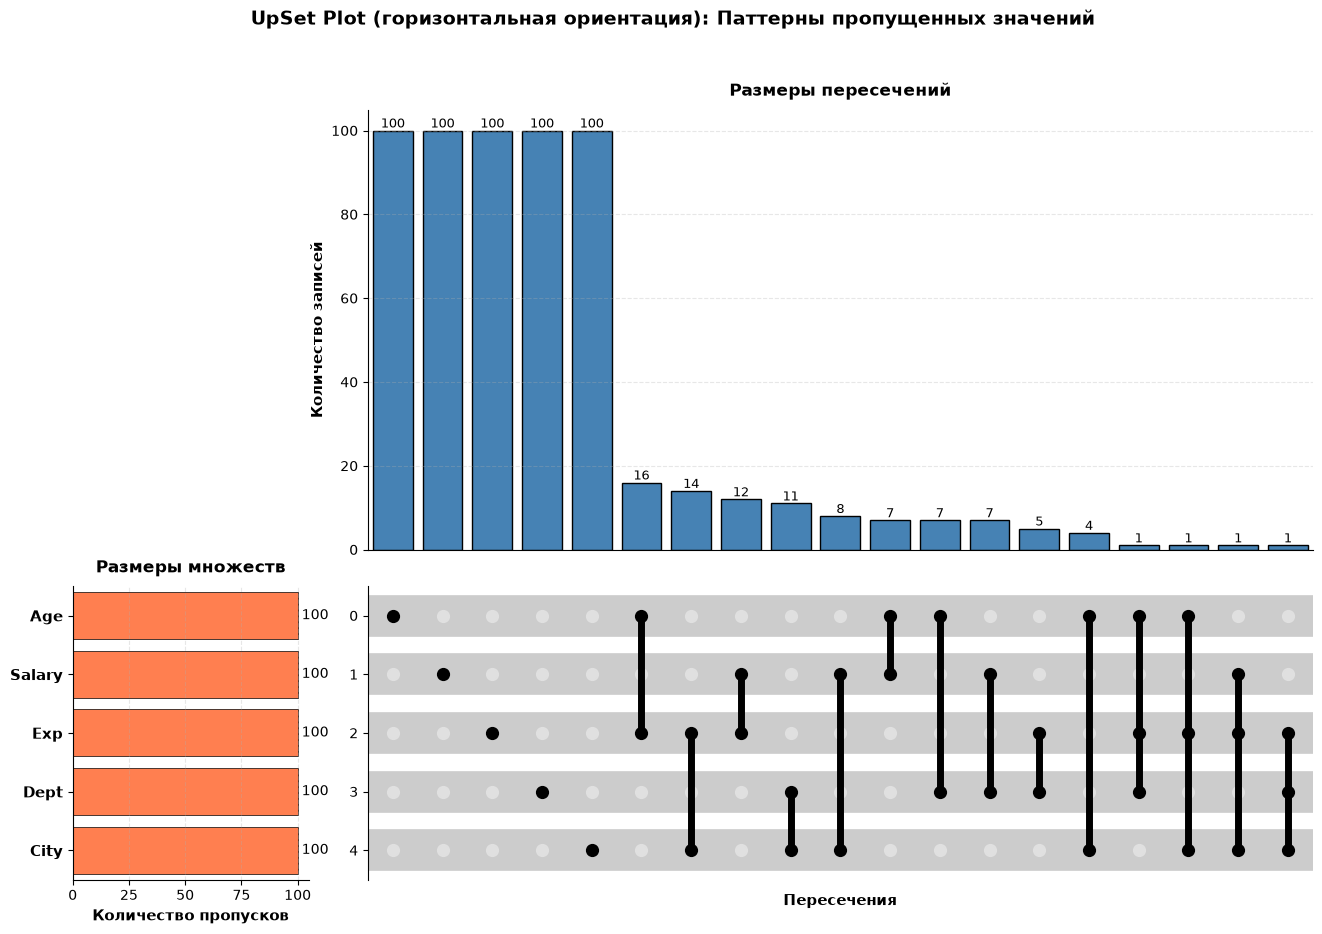

In [6]:
# Строим горизонтальный UpSet plot
print(" Строим горизонтальный UpSet plot...")

fig_horizontal = plot_upset(
    df, 
    indicator_cols, 
    abbreviations, 
    intersections, 
    orientation='horizontal', 
    max_intersections=15
)

# Сохраняем
plt.savefig('/home/fedosdan2/Study/TCP/seminars/sem_2_upset_plot/res/upset_horizontal.png', dpi=300, bbox_inches='tight')
print("✅ Сохранен как upset_horizontal.png")

# Отображаем
plt.show()

 Строим вертикальный UpSet plot...


/tmp/ipykernel_275533/1050397778.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


✅ Сохранен как upset_vertical.png


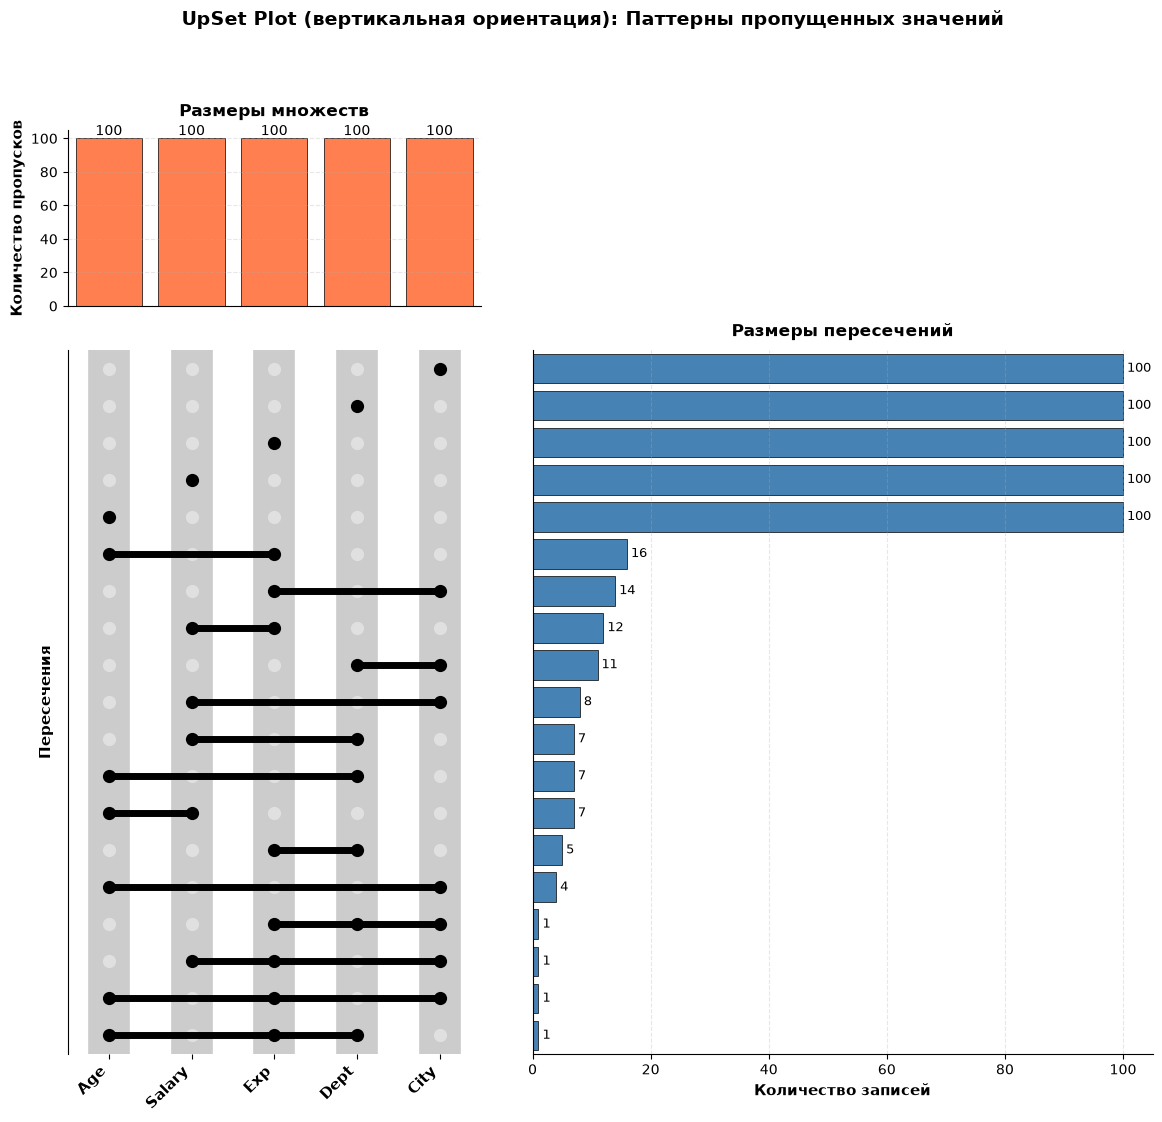

In [7]:
# Строим вертикальный UpSet plot
print(" Строим вертикальный UpSet plot...")

fig_vertical = plot_upset(
    df, 
    indicator_cols, 
    abbreviations, 
    intersections, 
    orientation='vertical', 
    max_intersections=15
)

# Сохраняем
plt.savefig('/home/fedosdan2/Study/TCP/seminars/sem_2_upset_plot/res/upset_vertical.png', dpi=300, bbox_inches='tight')
print("✅ Сохранен как upset_vertical.png")

# Отображаем
plt.show()